# Gradient Descent (from scratch, small steps)

**Goal:** Understand Gradient Descent as “parameter-tweaking to minimize a cost function.”

We’ll build Linear Regression using:
1. A baseline (closed-form solution / scikit-learn)
2. **Batch Gradient Descent**
3. **Stochastic Gradient Descent (SGD)** with a learning schedule
4. **Mini-batch Gradient Descent**

Along the way we’ll see:
- Why the **learning rate** matters (too small vs too large) :contentReference[oaicite:1]{index=1}
- Why **feature scaling** matters (elongated bowls make GD crawl) :contentReference[oaicite:2]{index=2}


## 0) Setup checklist (human steps)

1. Create a new notebook: `gradient_descent.ipynb` (done)
2. Confirm your kernel is Python 3
3. Install packages (if needed):
   - numpy
   - matplotlib
   - scikit-learn

In a terminal:
```bash
python -m pip install numpy matplotlib scikit-learn


In [1]:
## 1) Imports and reproducibility (Code cell)

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility: same random numbers each run
np.random.seed(42)


## 2) Make data for a simple line

We’ll generate points that roughly follow:

\[
y = 4 + 3x + \text{noise}
\]

This is a classic playground for gradient descent: we can see the “line” and measure how wrong a guess is.


In [2]:
m = 100  # number of training examples
X = 2 * np.random.rand(m, 1)     # x in [0, 2)
y = 4 + 3 * X + np.random.randn(m, 1)  # y = 4 + 3x + noise


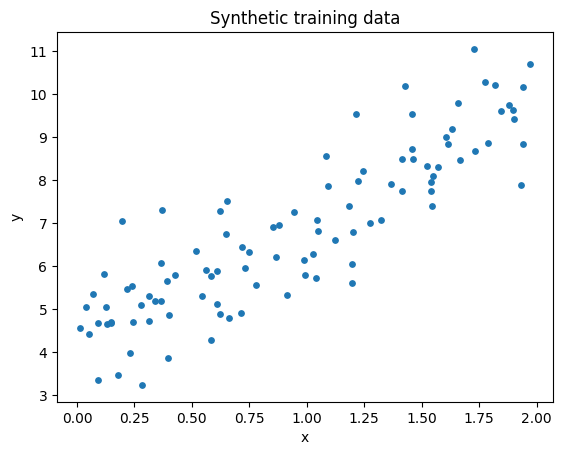

In [3]:
plt.figure()
plt.scatter(X, y, s=15)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic training data")
plt.show()


## 3) Add the bias term (intercept)

Linear regression with an intercept uses:

\[
\hat{y} = \theta_0 + \theta_1 x
\]

We can write this as a matrix multiplication by adding a column of 1s:

\[
X_b = [\mathbf{1} \ \ X]
\]

Then:

\[
\hat{y} = X_b \theta
\]

where \(\theta\) is a 2×1 vector: \(\theta_0\) and \(\theta_1\).


In [4]:
X_b = np.c_[np.ones((m, 1)), X]  # add x0 = 1 for all rows
X_b[:5]


array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788],
       [1.        , 1.19731697],
       [1.        , 0.31203728]])

## 4) Baseline solution (so we know what we’re aiming for)

For simple linear regression, there is a closed-form solution (often called the Normal Equation).
We’ll use scikit-learn as a reference point, then see if gradient descent finds something similar.

(Your PDF notes that Batch GD can match this baseline when learning rate is reasonable.) :contentReference[oaicite:3]{index=3}


In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

theta_baseline = np.array([lin_reg.intercept_[0], lin_reg.coef_[0][0]])
theta_baseline


array([4.21509616, 2.77011339])

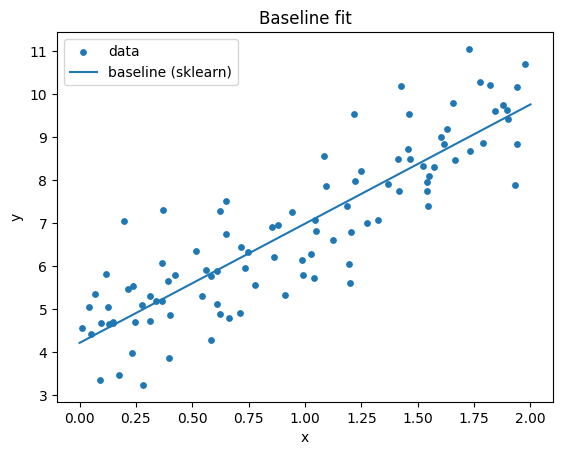

In [6]:
x_line = np.linspace(0, 2, 200).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

plt.figure()
plt.scatter(X, y, s=15, label="data")
plt.plot(x_line, y_line, label="baseline (sklearn)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Baseline fit")
plt.legend()
plt.show()


## 5) Batch Gradient Descent: the core idea

We choose a cost function. For linear regression, a common one is **Mean Squared Error (MSE)**:

\[
MSE(\theta) = \frac{1}{m}\sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2
\]

Gradient Descent updates parameters by stepping *downhill*:

\[
\theta \leftarrow \theta - \eta \nabla_\theta MSE(\theta)
\]

- \(\eta\) is the **learning rate** (step size) :contentReference[oaicite:4]{index=4}  
- Batch GD uses the **whole dataset** to compute each gradient step :contentReference[oaicite:5]{index=5}


## 6) We’ll write two small helpers

1. `mse(theta, X_b, y)` computes the cost
2. `mse_gradient(theta, X_b, y)` computes the gradient vector

The PDF gives a compact vector form for the gradient of MSE: :contentReference[oaicite:6]{index=6}  
and then the update step: :contentReference[oaicite:7]{index=7}
